In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

✅ Libraries imported


In [5]:
df = pd.read_csv('../../ML/data/calories.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
5,15130815,female,36,151.0,50.0,23.0,96.0,40.7,123.0
6,19602372,female,33,158.0,56.0,22.0,95.0,40.5,112.0
7,11117088,male,41,175.0,85.0,25.0,100.0,40.7,143.0
8,12132339,male,60,186.0,94.0,21.0,97.0,40.4,134.0
9,17964668,female,26,146.0,51.0,16.0,90.0,40.2,72.0


In [6]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB
None

=== Missing Values ===
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

=== Basic Statistics ===


,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [7]:
df = df.drop(columns=['User_ID'])
print(f"Shape after dropping User_ID: {df.shape}")
df.head()

Shape after dropping User_ID: (15000, 8)


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [8]:
print("=== Gender Distribution ===")
print(df['Gender'].value_counts())
print(f"\nGender unique values: {df['Gender'].unique()}")

=== Gender Distribution ===
Gender
female    7553
male      7447
Name: count, dtype: int64

Gender unique values: ['male' 'female']


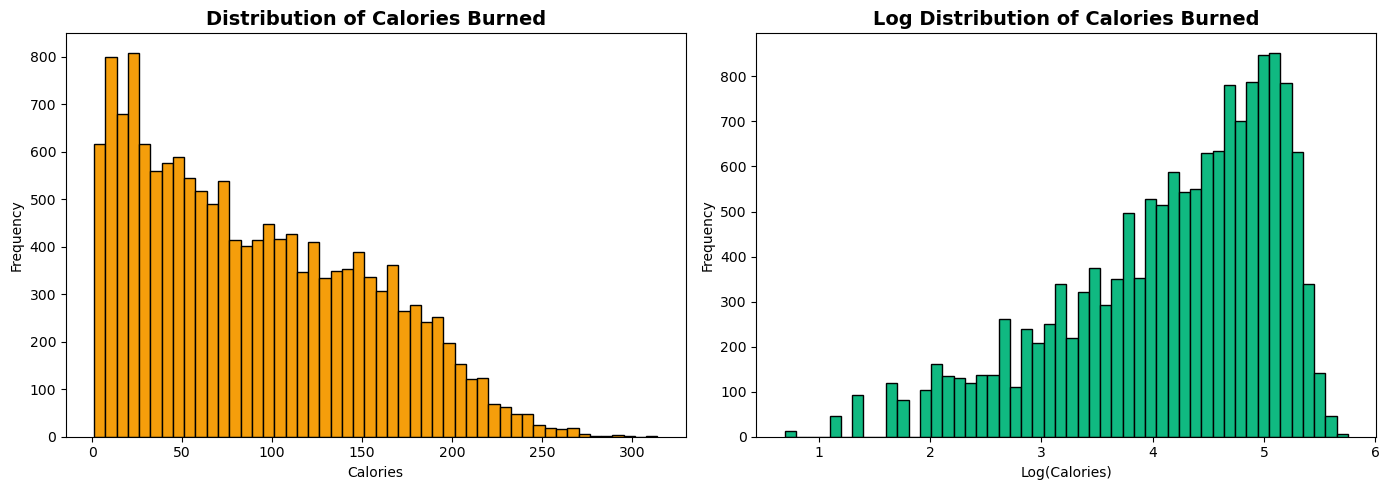

Skewness: 0.505


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Calories'], bins=50, color='#f59e0b', edgecolor='black')
axes[0].set_title('Distribution of Calories Burned', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Calories')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Calories']), bins=50, color='#10b981', edgecolor='black')
axes[1].set_title('Log Distribution of Calories Burned', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Calories)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('calories_distribution.png', dpi=150)
plt.show()
print(f"Skewness: {df['Calories'].skew():.3f}")

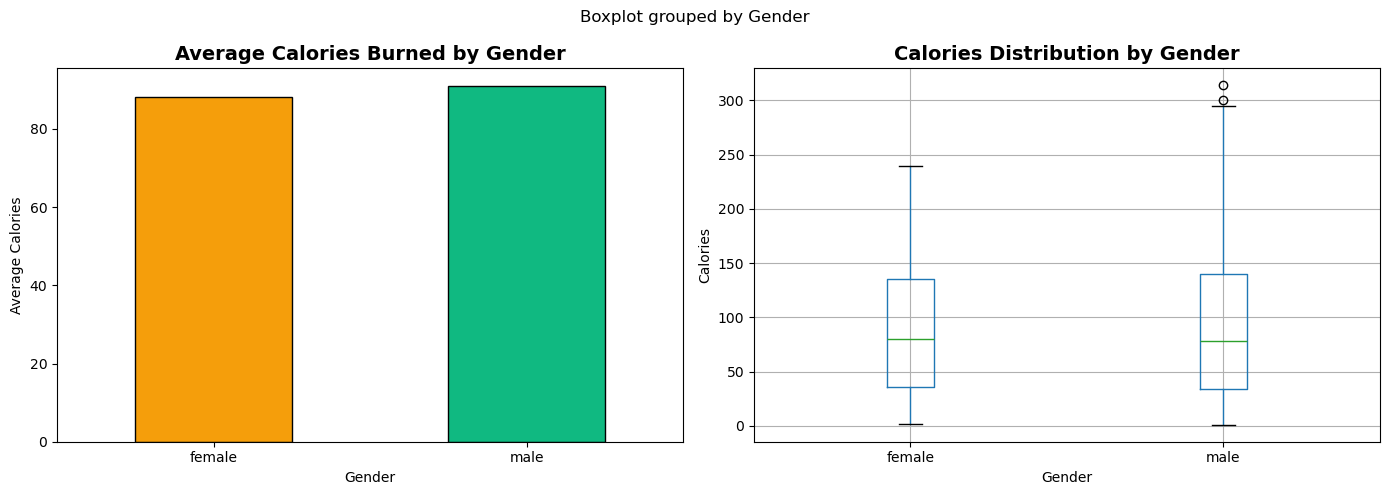

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Gender')['Calories'].mean().plot(
    kind='bar', ax=axes[0], color=['#f59e0b', '#10b981'], edgecolor='black'
)
axes[0].set_title('Average Calories Burned by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Average Calories')
axes[0].tick_params(axis='x', rotation=0)

df.boxplot(column='Calories', by='Gender', ax=axes[1])
axes[1].set_title('Calories Distribution by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Calories')

plt.tight_layout()
plt.savefig('calories_by_gender.png', dpi=150)
plt.show()

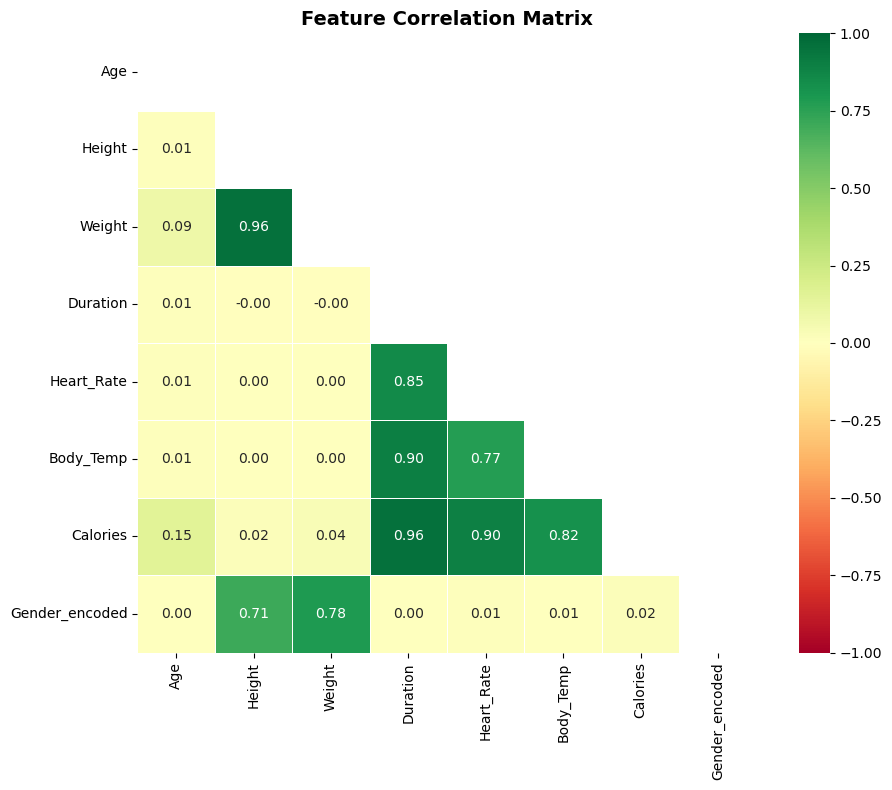


Top correlations with Calories:
Calories          1.000000
Duration          0.955421
Heart_Rate        0.897882
Body_Temp         0.824558
Age               0.154395
Weight            0.035481
Gender_encoded    0.022357
Height            0.017537
Name: Calories, dtype: float64


In [11]:
# Encode gender temporarily for correlation
df_corr = df.copy()
df_corr['Gender_encoded'] = (df_corr['Gender'] == 'male').astype(int)
df_corr = df_corr.drop(columns=['Gender'])

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

print("\nTop correlations with Calories:")
print(corr_matrix['Calories'].sort_values(ascending=False))

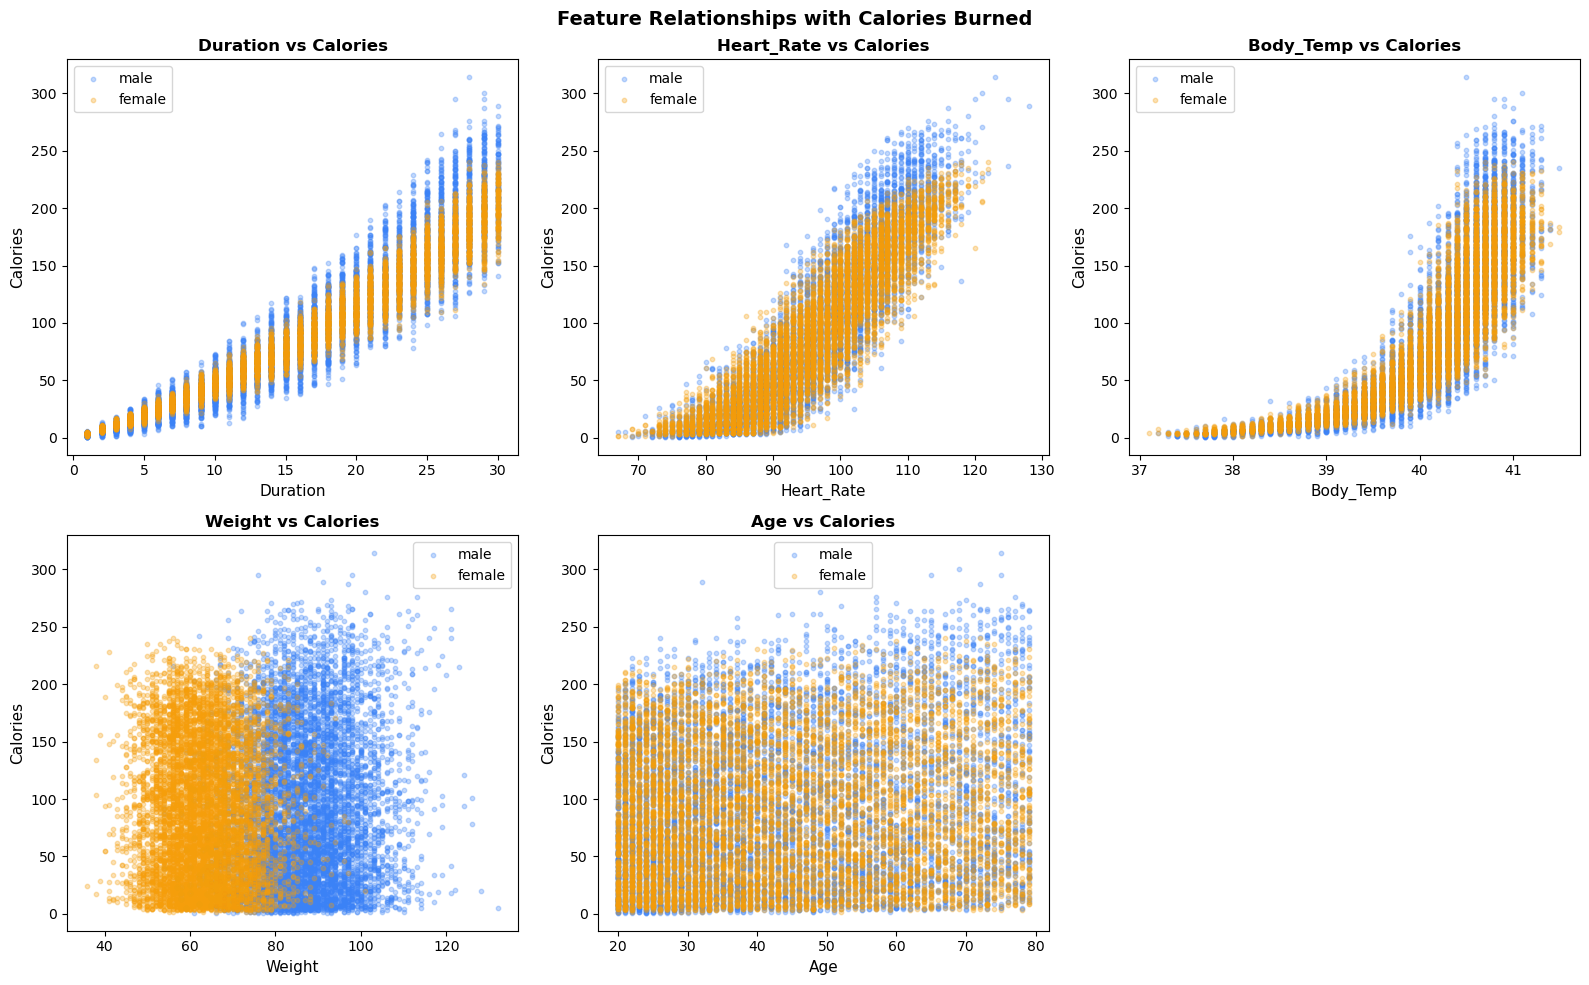

In [12]:
top_features = ['Duration', 'Heart_Rate', 'Body_Temp', 'Weight', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'male': '#3b82f6', 'female': '#f59e0b'}

for i, feat in enumerate(top_features):
    for gender, color in colors.items():
        subset = df[df['Gender'] == gender]
        axes[i].scatter(subset[feat], subset['Calories'],
                       alpha=0.3, s=10, color=color, label=gender)
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('Calories', fontsize=11)
    axes[i].set_title(f'{feat} vs Calories', fontsize=12, fontweight='bold')
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle('Feature Relationships with Calories Burned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_scatter.png', dpi=150)
plt.show()

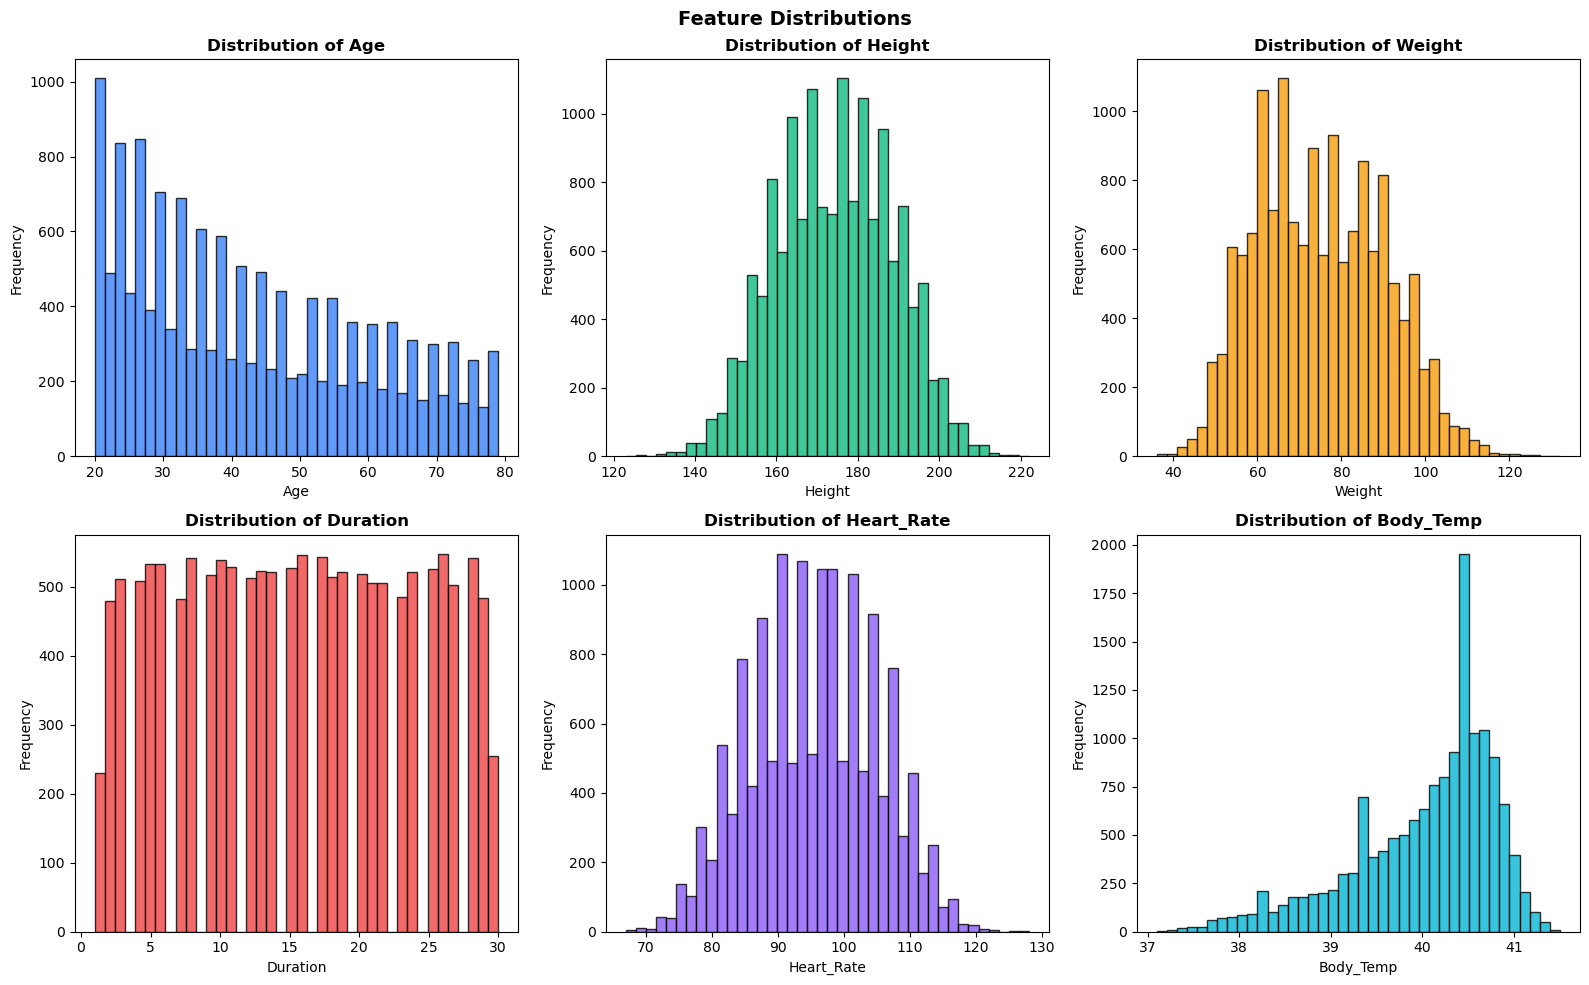

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
colors_list = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#06b6d4']

for i, (feat, color) in enumerate(zip(features_to_plot, colors_list)):
    axes[i//3][i%3].hist(df[feat], bins=40, color=color, edgecolor='black', alpha=0.8)
    axes[i//3][i%3].set_title(f'Distribution of {feat}', fontsize=12, fontweight='bold')
    axes[i//3][i%3].set_xlabel(feat)
    axes[i//3][i%3].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [14]:
# Encode Gender
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])  # male=1, female=0
print(f"Gender encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# BMI feature
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

# Interaction features
df['Weight_Duration'] = df['Weight'] * df['Duration']
df['HR_Duration']     = df['Heart_Rate'] * df['Duration']

print(f"\nNew features added: BMI, Weight_Duration, HR_Duration")
print(f"Dataset shape: {df.shape}")
df[['BMI', 'Weight_Duration', 'HR_Duration', 'Calories']].describe()

Gender encoding: {'female': 0, 'male': 1}

New features added: BMI, Weight_Duration, HR_Duration
Dataset shape: (15000, 12)


,BMI,Weight_Duration,HR_Duration,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,24.344900,1164.044733,1551.451133,89.539533
std,1.558784,675.731199,927.577028,62.456978
min,19.227688,49.000000,67.000000,1.000000
25%,23.243408,606.000000,737.500000,35.000000
50%,24.376731,1122.000000,1472.000000,79.000000
75%,25.492722,1650.000000,2323.000000,138.000000
max,29.069767,3570.000000,3840.000000,314.000000


In [15]:
feature_cols = [
    'Gender_encoded', 'Age', 'Height', 'Weight',
    'Duration', 'Heart_Rate', 'Body_Temp',
    'BMI', 'Weight_Duration', 'HR_Duration'
]

X = df[feature_cols]
y = df['Calories']

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nCalories range: {y.min():.1f} — {y.max():.1f}")
print(f"Calories mean:  {y.mean():.1f}")

Features: ['Gender_encoded', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI', 'Weight_Duration', 'HR_Duration']
X shape: (15000, 10)
y shape: (15000,)

Calories range: 1.0 — 314.0
Calories mean:  89.5


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"Train/Test split: 80/20")

Training set:   12000 samples
Test set:       3000 samples
Train/Test split: 80/20


In [17]:
model = XGBRegressor(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    gamma           = 0.1,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    early_stopping_rounds = 20,
    eval_metric     = 'rmse',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ Model trained successfully")

[0]	validation_0-rmse:60.53205
[50]	validation_0-rmse:6.36339
[100]	validation_0-rmse:2.07741
[150]	validation_0-rmse:1.67149
[200]	validation_0-rmse:1.54960
[250]	validation_0-rmse:1.46446
[300]	validation_0-rmse:1.41212
[350]	validation_0-rmse:1.36971
[400]	validation_0-rmse:1.33635
[450]	validation_0-rmse:1.30559
[499]	validation_0-rmse:1.27816

✅ Model trained successfully


In [18]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  R² Score:  {r2:.4f}  ({r2*100:.2f}%)")
print(f"  RMSE:      {rmse:.2f} calories")
print(f"  MAE:       {mae:.2f} calories")
print("=" * 40)

if r2 >= 0.95:
    print("🟢 Excellent model performance")
elif r2 >= 0.85:
    print("🟡 Good model performance")
else:
    print("🔴 Model needs improvement")

       MODEL EVALUATION RESULTS
  R² Score:  0.9996  (99.96%)
  RMSE:      1.28 calories
  MAE:       0.89 calories
🟢 Excellent model performance


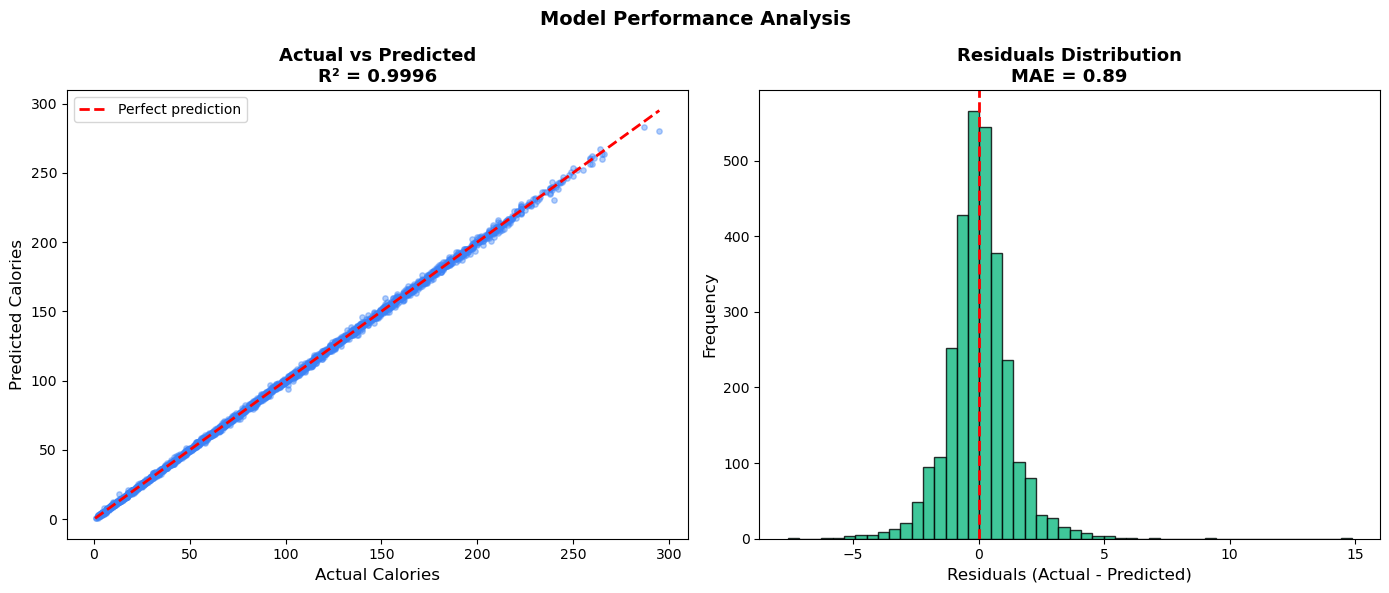

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='#3b82f6')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Calories', fontsize=12)
axes[0].set_ylabel('Predicted Calories', fontsize=12)
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='#10b981', edgecolor='black', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Residuals Distribution\nMAE = {mae:.2f}', fontsize=13, fontweight='bold')

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_performance.png', dpi=150)
plt.show()

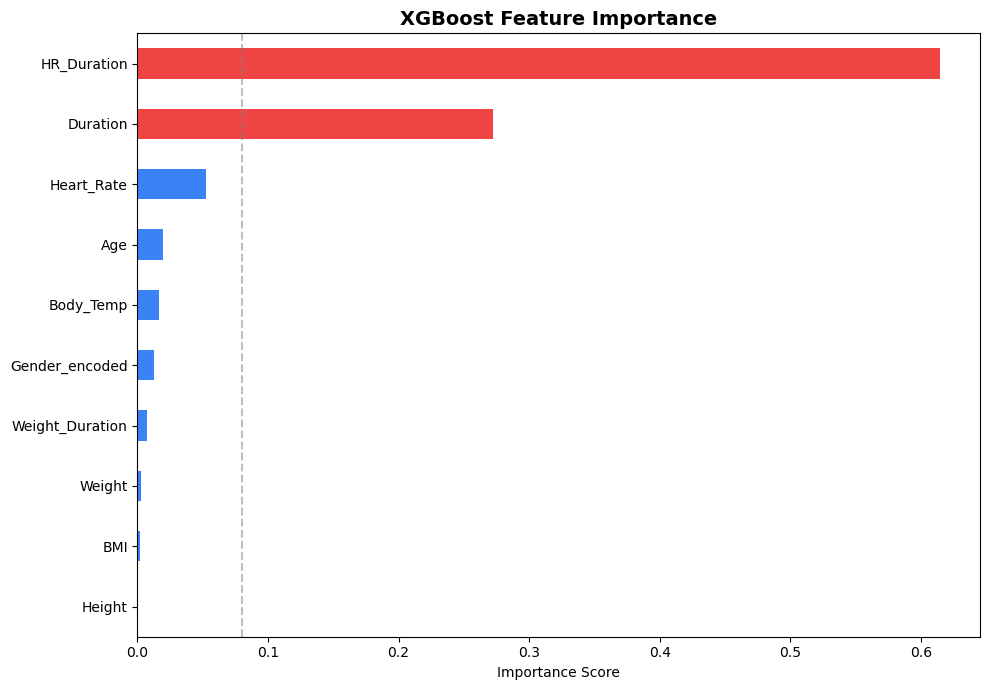


Feature Importance Ranking:
  HR_Duration          █████████████████████████████████████████████████████████████ 0.6145
  Duration             ███████████████████████████ 0.2720
  Heart_Rate           █████ 0.0526
  Age                  █ 0.0193
  Body_Temp            █ 0.0169
  Gender_encoded       █ 0.0123
  Weight_Duration       0.0073
  Weight                0.0030
  BMI                   0.0018
  Height                0.0005


In [20]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#ef4444' if v > 0.15 else '#f59e0b' if v > 0.08 else '#3b82f6'
          for v in feat_importance.values]
feat_importance.plot(kind='barh', color=colors)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.08, color='gray', linestyle='--', alpha=0.5, label='Threshold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Ranking:")
for feat, imp in feat_importance.sort_values(ascending=False).items():
    bar = '█' * int(imp * 100)
    print(f"  {feat:<20} {bar} {imp:.4f}")

In [21]:
import json

# Save model
joblib.dump(model, 'calories_model.pkl')

# Save feature columns and label encoder
model_metadata = {
    'feature_cols': feature_cols,
    'gender_encoding': {'male': 1, 'female': 0},
    'model_type': 'XGBoost Regressor',
    'r2_score': round(r2, 4),
    'rmse': round(rmse, 2),
    'mae': round(mae, 2),
    'training_samples': len(X_train),
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Model saved: calories_model.pkl")
print("✅ Metadata saved: model_metadata.json")
print(f"\nModel size: {joblib.dump(model, 'calories_model.pkl')[0]}")
print(f"\nMetadata:")
print(json.dumps(model_metadata, indent=2))

✅ Model saved: calories_model.pkl
✅ Metadata saved: model_metadata.json

Model size: calories_model.pkl

Metadata:
{
  "feature_cols": [
    "Gender_encoded",
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp",
    "BMI",
    "Weight_Duration",
    "HR_Duration"
  ],
  "gender_encoding": {
    "male": 1,
    "female": 0
  },
  "model_type": "XGBoost Regressor",
  "r2_score": 0.9996,
  "rmse": 1.28,
  "mae": 0.89,
  "training_samples": 12000
}


In [23]:
# ── CELL 20 — Sanity Check with multiple athletes ──

test_cases = [
    {
        'label':          'Male, 23yrs, 70kg — 30min football',
        'Gender_encoded': 1,
        'Age':            23,
        'Height':         175.0,
        'Weight':         70.0,
        'Duration':       30.0,
        'Heart_Rate':     155.0,
        'Body_Temp':      39.5,
        'BMI':            70 / (1.75**2),
        'Weight_Duration': 70 * 30,
        'HR_Duration':    155 * 30,
    },
    {
        'label':          'Female, 25yrs, 58kg — 20min running',
        'Gender_encoded': 0,
        'Age':            25,
        'Height':         163.0,
        'Weight':         58.0,
        'Duration':       20.0,
        'Heart_Rate':     145.0,
        'Body_Temp':      39.2,
        'BMI':            58 / (1.63**2),
        'Weight_Duration': 58 * 20,
        'HR_Duration':    145 * 20,
    },
    {
        'label':          'Male, 40yrs, 85kg — 25min gym',
        'Gender_encoded': 1,
        'Age':            40,
        'Height':         180.0,
        'Weight':         85.0,
        'Duration':       25.0,
        'Heart_Rate':     130.0,
        'Body_Temp':      39.0,
        'BMI':            85 / (1.80**2),
        'Weight_Duration': 85 * 25,
        'HR_Duration':    130 * 25,
    },
    {
        'label':          'Female, 19yrs, 55kg — 10min light yoga',
        'Gender_encoded': 0,
        'Age':            19,
        'Height':         160.0,
        'Weight':         55.0,
        'Duration':       10.0,
        'Heart_Rate':     85.0,
        'Body_Temp':      38.2,
        'BMI':            55 / (1.60**2),
        'Weight_Duration': 55 * 10,
        'HR_Duration':    85 * 10,
    },
]

print("=" * 55)
print("         SANITY CHECK — MULTIPLE ATHLETES")
print("=" * 55)

feature_cols = [
    'Gender_encoded', 'Age', 'Height', 'Weight',
    'Duration', 'Heart_Rate', 'Body_Temp',
    'BMI', 'Weight_Duration', 'HR_Duration'
]

all_pass = True
for case in test_cases:
    label = case.pop('label')
    df_test = pd.DataFrame([case])
    pred = model.predict(df_test[feature_cols])[0]

    # Range based on duration (training data: 1-30min → 1-314 cal)
    min_expected = case['Duration'] * 2
    max_expected = case['Duration'] * 15
    status = "✅" if min_expected <= pred <= max_expected else "⚠️ "
    if status == "⚠️ ":
        all_pass = False

    print(f"\n  {label}")
    print(f"  Duration: {case['Duration']}min | HR: {case['Heart_Rate']}bpm | Temp: {case['Body_Temp']}°C")
    print(f"  Predicted: {pred:.1f} cal  {status}")

print("\n" + "=" * 55)
if all_pass:
    print("  🟢 All predictions within expected ranges")
else:
    print("  🟡 Some predictions outside expected range — check extrapolation")
print("=" * 55)

         SANITY CHECK — MULTIPLE ATHLETES

  Male, 23yrs, 70kg — 30min football
  Duration: 30.0min | HR: 155.0bpm | Temp: 39.5°C
  Predicted: 237.4 cal  ✅

  Female, 25yrs, 58kg — 20min running
  Duration: 20.0min | HR: 145.0bpm | Temp: 39.2°C
  Predicted: 191.2 cal  ✅

  Male, 40yrs, 85kg — 25min gym
  Duration: 25.0min | HR: 130.0bpm | Temp: 39.0°C
  Predicted: 237.7 cal  ✅

  Female, 19yrs, 55kg — 10min light yoga
  Duration: 10.0min | HR: 85.0bpm | Temp: 38.2°C
  Predicted: 37.0 cal  ✅

  🟢 All predictions within expected ranges
